# Autoencoders para Colorear Imagenes en Escalas de Grises
Este problema de colorización de imágenes usando autoencoders requiere desarrollar un modelo que aprenda a mapear imágenes en escala de grises a sus versiones en color. El enfoque consiste en crear una arquitectura encoder-decoder con capas convolucionales.
Estructura general del modelo:

 * **Encoder:** utiliza capas convolucionales con pooling para reducir progresivamente las dimensiones espaciales mientras extrae características relevantes de la imagen en escala de grises. Esta parte del modelo aprende representaciones compactas (representación o espacio latente) que capturan la información esencial para la colorización.
 * **Decoder:** reconstruye la imagen a color desde la representación latente, aumentando gradualmente las dimensiones espaciales hasta alcanzar el tamaño original. Esta implementación utiliza capas Conv2DTranspose que realizan la operación inversa a la convolución tradicional. La **Conv2DTranspose** aprende automáticamente los pesos óptimos para el upsampling mediante el proceso de entrenamiento, generando nuevos valores de píxeles basados en patrones aprendidos en lugar de simplemente duplicar píxeles existentes. Esta técnica es más sofisticada computacionalmente pero genera resultados de mayor calidad.

#### Capa Conv2DTranspose
La capa de Conv2DTranspose (convolución transpuesta o deconvolución) realiza una convolución inversa que aumenta las dimensiones espaciales mientras aplica filtros aprendibles. A diferencia del simple upsampling, esta capa genera nuevos valores de píxeles mediante la combinación ponderada de los valores de entrada, utilizando kernels entrenables que optimizan la reconstrucción de la imagen. El modelo típicamente usa filtros de tamaño 3x3 o 5x5 con funciones de activación ReLU en las capas intermedias.
La ventaja principal de este enfoque es su capacidad de **aprendizaje adaptativo** y **mayor calidad** en la reconstrucción de detalles, aunque requiere más recursos computacionales y tiempo de entrenamiento respecto de otros métodos.

---
---


### Montar la carpeta de Google Drive y definir constantes para trabajar

In [1]:
ColabNotebook = 'google.colab' in str(get_ipython())

if ColabNotebook:
    # monta G-drive en entorno COLAB
    from google.colab import drive
    drive.mount('/content/drive/')

    # carpeta donde se encuentran archivos .py auxiliares
    FUENTES_DIR = '/content/drive/MyDrive/Colab Notebooks/FUENTES/'
    DATOS_DIR = '/content/drive/MyDrive/Colab Notebooks/DATOS/'      # carpeta donde se encuentran los datasets
    LOCAL_DIR = './DATOS/'  # carpeta local en maquina virtual
else:
    # configuración para notebook con instalación LOCAL
    FUENTES_DIR = '../../FUENTES'         # carpeta donde se encuentran archivos .py auxiliares
    DATOS_DIR   = '../../DATOS/' # carpeta donde se encuentran los datasets
    LOCAL_DIR = './DATOS/'

import os
MODELOS_DIR = os.path.abspath(DATOS_DIR+'../MODELOS/')
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

# agrega ruta de busqueda donde tenemos archivos .py
import sys
sys.path.append(FUENTES_DIR)

### Inclusión de Paquetes para Trabajar

In [2]:
#!pip install tqdm
import numpy as np
import re
import matplotlib.pyplot as plt
import os
import shutil
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, callbacks
from tensorflow.keras.preprocessing.image import img_to_array
from tqdm import tqdm
from zipfile import ZipFile
from PIL import Image
import glob


#!dir $LOCAL_DIR

## Preparación del Archivo de Datos
#### Copia de Archivo y Descompresión

Recupera el archivo comprimido de la carpeta de g-drive y lo descomprime en una carpeta local para hacer más rápido el acceso a las imágenes. Realiza la descompresión archivo por archivo para visualizar el progreso (útil cuando el archivo es grande).

In [3]:
ZIP_ARCH = 'landscape_color_gray.zip'  # Archivo comprimido

# Verificar y crear la carpeta de datos local si no existe
if not os.path.exists(LOCAL_DIR):
    os.makedirs(LOCAL_DIR)

# Comprueba la existencia del archivo en la carpeta de destino
zip_path = os.path.join(LOCAL_DIR, ZIP_ARCH)
if not os.path.exists(zip_path):
    source_file = os.path.join(DATOS_DIR, ZIP_ARCH)
    shutil.copy(source_file, LOCAL_DIR)  # Copiar el archivo a la carpeta local

# Descompresión con barra de progreso
with ZipFile(zip_path, 'r') as zip_ref:
    files = zip_ref.infolist()
    for file in tqdm(files, desc='Extrayendo', unit=' archivo'):
        zip_ref.extract(file, LOCAL_DIR)

print(f"\nEl archivo {ZIP_ARCH} se ha copiado y descomprimido en {LOCAL_DIR}.")

Extrayendo: 100%|██████████| 14258/14258 [01:31<00:00, 156.34 archivo/s]


El archivo landscape_color_gray.zip se ha copiado y descomprimido en ./DATOS/.


#### Preparación del Dataset

En este bloque se realiza la preparación del conjunto de datos para entrenar y validar la red neuronal que colorea imágenes. Se parte de un conjunto de tuplas o pares de imágenes donde, donde la primera está en escala de grises (entrada del modelo) y la segunda corresponde a la versión en color (objetivo del modelo). Los pasos realizados en este proceso de generación de este conjunto de datos son:
* **Carga de imágenes**: Se leen las imágenes desde disco, asegurando que cada imagen en grises tenga su contraparte en color con el mismo nombre de archivo.
* **Preprocesamiento**: Las imágenes son redimensionadas a un tamaño fijo y normalizadas para que sus valores estén entre 0 y 1.
* **Estructuración como dataset TensorFlow**: Los datos se organizan en un objeto ***tf.data.Dataset***, que permite aplicar transformaciones eficientes como:
  * Mezclar aleatoriamente los ejemplos.
  * Aplicar procesamiento en paralelo.
  * Agrupar en lotes para entrenamiento por mini-lotes(minibatches).
  * Prefetch para optimizar el flujo de datos al modelo.
* **División entrenamiento-validación**:
  * **Entrenamiento (75%)**: utilizado por el modelo para aprender los patrones de coloreado.
  * **Validación (25%)**: utilizado para evaluar el rendimiento del modelo durante el entrenamiento y evitar sobreajuste.

In [4]:
# Configuración
TAM_IMG = 96   # Tamaño de la imagen que será procesada por la red
FACTOR_ENTRENA = 0.75  # Proporción del dataset para entrenamiento
TAM_LOTE = 64  # Tamaño de los lotes

ruta_color = 'landscape Images/color/'
ruta_grises = 'landscape Images/gray/'

# Función optimizada para cargar y procesar imágenes
@tf.function # Esto convierte una función python en una versión tensorflow con el objetivo de mejorar el rendimiento
def load_and_process(gray_path, rgb_path, img_size=(TAM_IMG, TAM_IMG)):
    # Carga paralela de ambos archivos
    gray_img = tf.io.read_file(gray_path)
    rgb_img = tf.io.read_file(rgb_path)
    # Decodificación paralela
    gray_img = tf.image.decode_jpeg(gray_img, channels=1)
    rgb_img = tf.image.decode_jpeg(rgb_img, channels=3)
    # Redimensionar
    gray_img = tf.image.resize(gray_img, img_size)
    rgb_img = tf.image.resize(rgb_img, img_size)
    # Normalizar
    gray_img = tf.cast(gray_img, tf.float32) / 255.0
    rgb_img = tf.cast(rgb_img, tf.float32) / 255.0

    return gray_img, rgb_img

# Función optimizada para cargar el dataset
def cargar_dataset(gray_files, rgb_files, batch_size=32, shuffle_buffer=1000):
    # Crear dataset directamente desde las listas de archivos
    dataset = tf.data.Dataset.from_tensor_slices((gray_files, rgb_files))

    # Shuffle antes de mapear para mejor rendimiento
    if shuffle_buffer:
        dataset = dataset.shuffle(shuffle_buffer, reshuffle_each_iteration=False)
    # Mapeo paralelizado y cacheado
    dataset = dataset.map(
        load_and_process,
        num_parallel_calls=tf.data.AUTOTUNE
    )
    # Batch y prefetch
    dataset = dataset.batch(batch_size, drop_remainder=True)
    dataset = dataset.prefetch(buffer_size=tf.data.AUTOTUNE)

    return dataset

# Cargar listas de archivos una sola vez
gray_files = sorted([
    os.path.join(LOCAL_DIR+ruta_grises, f) for f in os.listdir(LOCAL_DIR+ruta_grises) if f.endswith('.jpg')
])

rgb_files = [
    f.replace('gray', 'color') for f in gray_files
]

# Verificar correspondencia
assert all(os.path.basename(g) == os.path.basename(r) for g, r in zip(gray_files, rgb_files)), \
       "¡Archivos no coincidentes!"

# Dividir dataset en train/val
cant_total = len(gray_files)
cant_entrena = int(FACTOR_ENTRENA * cant_total)

# Crear datasets directamente divididos
train_gray = gray_files[:cant_entrena]
train_rgb = rgb_files[:cant_entrena]

val_gray = gray_files[cant_entrena:]
val_rgb = rgb_files[cant_entrena:]

# Crear datasets finales
dataset_entrena = cargar_dataset(
    train_gray,
    train_rgb,
    batch_size=TAM_LOTE,
    shuffle_buffer=1000
)

dataset_valida = cargar_dataset(
    val_gray,
    val_rgb,
    batch_size=TAM_LOTE,
    shuffle_buffer=0  # No necesitamos shuffle para validación
)

# Opcional: Cachear los datasets si caben en memoria
dataset_entrena = dataset_entrena.cache()
dataset_valida = dataset_valida.cache()

**Gráficar Algunas Imagenes**

Gráfico en escalas de grises y su versión correspondiente en color

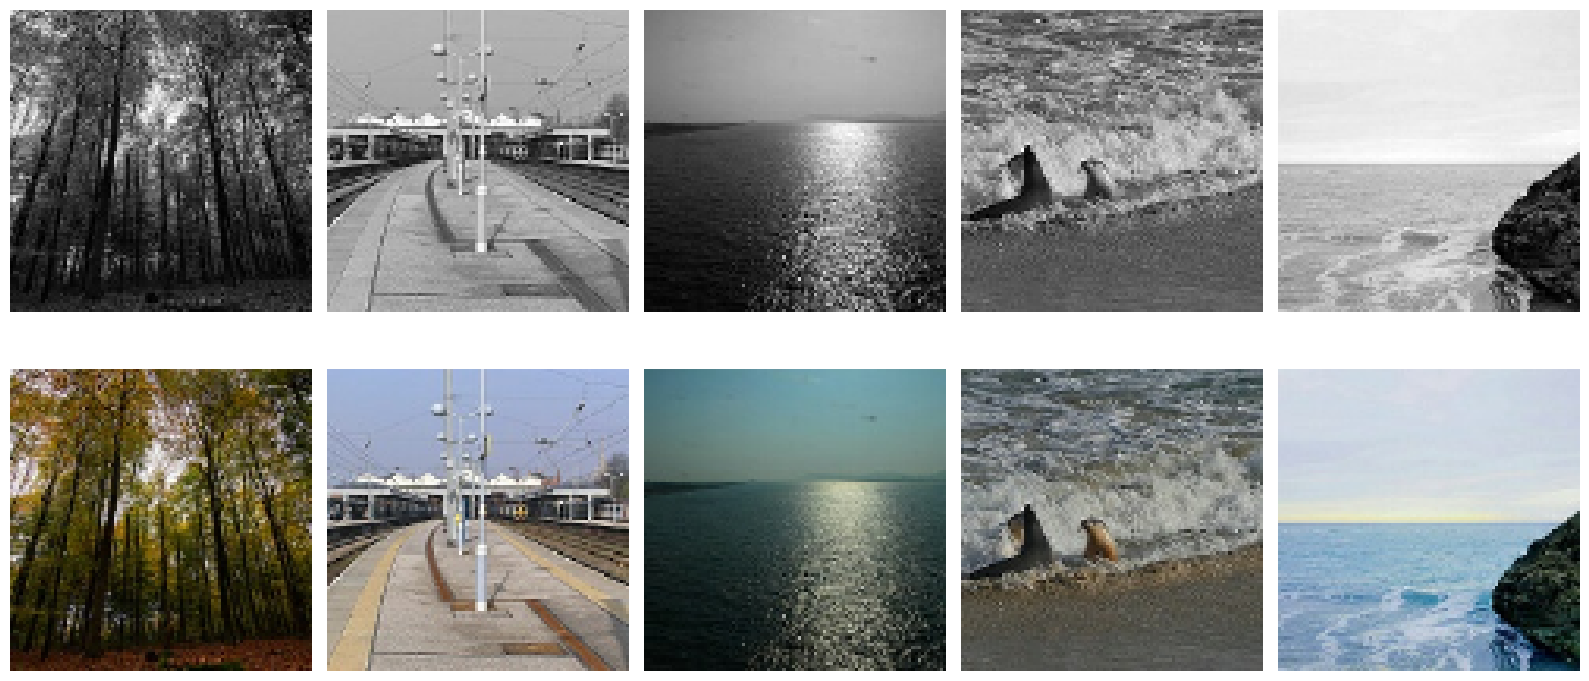

In [5]:
def plot_images_from_tensor(grayscale_images, color_images, num_images=5):
    # Selección directa sin escalar
    color_np = color_images[:num_images].numpy()
    gray_np = grayscale_images[:num_images].numpy().squeeze(-1)

    # Plot
    fig, axes = plt.subplots(2, num_images, figsize=(16, 8))
    if num_images == 1:
        axes = axes.reshape(2, 1)

    for i in range(num_images):
        axes[0, i].imshow(gray_np[i], cmap='gray')  # Grayscale
        axes[1, i].imshow(color_np[i])              # RGB
        axes[0, i].axis('off')
        axes[1, i].axis('off')

    axes[0, 0].set_ylabel('Color', fontsize=12)
    axes[1, 0].set_ylabel('Grises', fontsize=12)

    plt.tight_layout()
    plt.show()


# Obtener un batch de tu dataset
lote_imagenes = next(iter(dataset_entrena.take(1)))  # Obtiene el primer batch con tuplas
lote_grises, lote_color = lote_imagenes

plot_images_from_tensor(lote_grises, lote_color, num_images=5)

**Construccion del modelo**

Construye el modelo utilizando capas convolucionales que reducen el tamaño de la imagen a través del stride e incrementan la cantidad de filtros hasta llegar al espacio de representación latente. Luego se realiza el proceso inverso agregando capas convolucionales que decrementan la cantidad de filtros y capas de Upsampling para ir recuperando el tamaño de la imagen al original.

In [73]:
from tensorflow.keras import layers, models, optimizers, activations

def crear_modelo(img_h, img_w, activ='relu'):
    inputs = layers.Input(shape=(img_h, img_w, 1))

    # --- Encoder ---
    x = layers.Conv2D(64, (3,3), activation=activ, padding='same')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(64, (3,3), activation=activ, padding='same', strides=2)(x)
    x = layers.BatchNormalization()(x)

    x = layers.Conv2D(128, (3,3), activation=activ, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(128, (3,3), activation=activ, padding='same', strides=2)(x)
    x = layers.BatchNormalization()(x)

    x = layers.Conv2D(256, (3,3), activation=activ, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(256, (3,3), activation=activ, padding='same', strides=2)(x)
    x = layers.BatchNormalization()(x)

    # --- Bottleneck ---
    x = layers.Conv2D(512, (3,3), activation=activ, padding='same')(x)
    x = layers.BatchNormalization()(x)
    #x = layers.Conv2D(512, (3,3), activation=activ, padding='same')(x)
    #x = layers.BatchNormalization()(x)

    # --- Decoder ---
    x = layers.Conv2DTranspose(256, (3,3), activation=activ, padding='same', strides=2)(x)
    x = layers.Conv2D(256, (3,3), activation=activ, padding='same')(x)
    x = layers.BatchNormalization()(x)

    x = layers.Conv2DTranspose(128, (3,3), activation=activ, padding='same', strides=2)(x)
    x = layers.Conv2D(128, (3,3), activation=activ, padding='same')(x)
    x = layers.BatchNormalization()(x)

    x = layers.Conv2DTranspose(64, (3,3), activation=activ, padding='same', strides=2)(x)
    x = layers.Conv2D(64, (3,3), activation=activ, padding='same')(x)
    x = layers.BatchNormalization()(x)

    # Output
    outputs = layers.Conv2D(3, (3,3), activation='sigmoid', padding='same')(x)

    return models.Model(inputs=inputs, outputs=outputs)

    
# Crear y compilar el modelo
model = crear_modelo(TAM_IMG, TAM_IMG, activ='leaky_relu')
model.compile(optimizer=optimizers.Adam(learning_rate=0.0005),
                       loss='mean_absolute_error')

model.summary()

Model: "functional_23"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_11 (InputLayer)     │ (None, 96, 96, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_107 (Conv2D)             │ (None, 96, 96, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_53          │ (None, 96, 96, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_108 (Conv2D)             │ (None, 48, 48, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_54          │ (None, 48, 48, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_109 (Conv2D)             │ (None, 48, 48, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_55          │ (None, 48, 48, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_110 (Conv2D)             │ (None, 24, 24, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_56          │ (None, 24, 24, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_111 (Conv2D)             │ (None, 24, 24, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_57          │ (None, 24, 24, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_112 (Conv2D)             │ (None, 12, 12, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_58          │ (None, 12, 12, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_113 (Conv2D)             │ (None, 12, 12, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_59          │ (None, 12, 12, 512)    │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_33             │ (None, 24, 24, 256)    │     1,179,904 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_114 (Conv2D)             │ (None, 24, 24, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_60          │ (None, 24, 24, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_34             │ (None, 48, 48, 128)    │       295,040 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_115 (Conv2D)             │ (None, 48, 48, 128)    │       147,58

 Total params: 4,656,899 (17.76 MB)

 Trainable params: 4,653,187 (17.75 MB)

 Non-trainable params: 3,712 (14.50 KB)

**Entrenamiento**

In [74]:
es = callbacks.EarlyStopping(
    monitor='val_loss',  # Monitorea la pérdida de validación
    patience=15,         # Número de épocas sin mejora antes de detener
    restore_best_weights=True,  # Restaura los mejores pesos encontrados
)

history = model.fit(
    dataset_entrena,
    validation_data=dataset_valida,
    epochs=500,
    callbacks=[es],
    verbose=1
)

Epoch 1/500
83/83 ━━━━━━━━━━━━━━━━━━━━ 26s 188ms/step - loss: 0.1379 - val_loss: 0.2224
Epoch 2/500
83/83 ━━━━━━━━━━━━━━━━━━━━ 19s 233ms/step - loss: 0.0916 - val_loss: 0.2087
Epoch 3/500
83/83 ━━━━━━━━━━━━━━━━━━━━ 22s 267ms/step - loss: 0.0839 - val_loss: 0.2010
Epoch 4/500
83/83 ━━━━━━━━━━━━━━━━━━━━ 23s 276ms/step - loss: 0.0796 - val_loss: 0.1812
Epoch 5/500
83/83 ━━━━━━━━━━━━━━━━━━━━ 26s 310ms/step - loss: 0.0765 - val_loss: 0.1542
Epoch 6/500
83/83 ━━━━━━━━━━━━━━━━━━━━ 23s 278ms/step - loss: 0.0744 - val_loss: 0.1252
Epoch 7/500
83/83 ━━━━━━━━━━━━━━━━━━━━ 23s 278ms/step - loss: 0.0732 - val_loss: 0.0999
Epoch 8/500
83/83 ━━━━━━━━━━━━━━━━━━━━ 23s 277ms/step - loss: 0.0717 - val_loss: 0.0823
Epoch 9/500
83/83 ━━━━━━━━━━━━━━━━━━━━ 23s 278ms/step - loss: 0.0702 - val_loss: 0.0984
Epoch 10/500
83/83 ━━━━━━━━━━━━━━━━━━━━ 26s 308ms/step - loss: 0.0690 - val_loss: 0.0851
Epoch 11/500
83/83 ━━━━━━━━━━━━━━━━━━━━ 22s 262ms/step - loss: 0.0679 - val_loss: 0.0722
Epoch 12/500
83/83 ━━━━━━━━━━━

**Evaluación con datos de prueba**

In [75]:
model.evaluate(dataset_valida)

27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 90ms/step - loss: 0.0557


0.05456310883164406

In [80]:
import plotly.graph_objects as go

history_dict = history.history
epochs = list(range(1, len(next(iter(history_dict.values()))) + 1))

fig = go.Figure()

for metric_name, values in history_dict.items():
    fig.add_trace(go.Scatter(
        x=epochs,
        y=values,
        mode='lines+markers',
        name=metric_name,
        line=dict(width=2),
        marker=dict(size=4)
    ))

fig.update_layout(
    title='Evolución del Entrenamiento',
    xaxis_title='Época',
    yaxis_title='Valor',
    hovermode='x unified',
    template='plotly_white',
    width=800,
    height=500
)

fig.show()

**Visualización de Resultados**

Muestra varias imagenes en escalas de grises con la versión de su imagen a color y la versión de la imagen coloreada

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 391ms/step


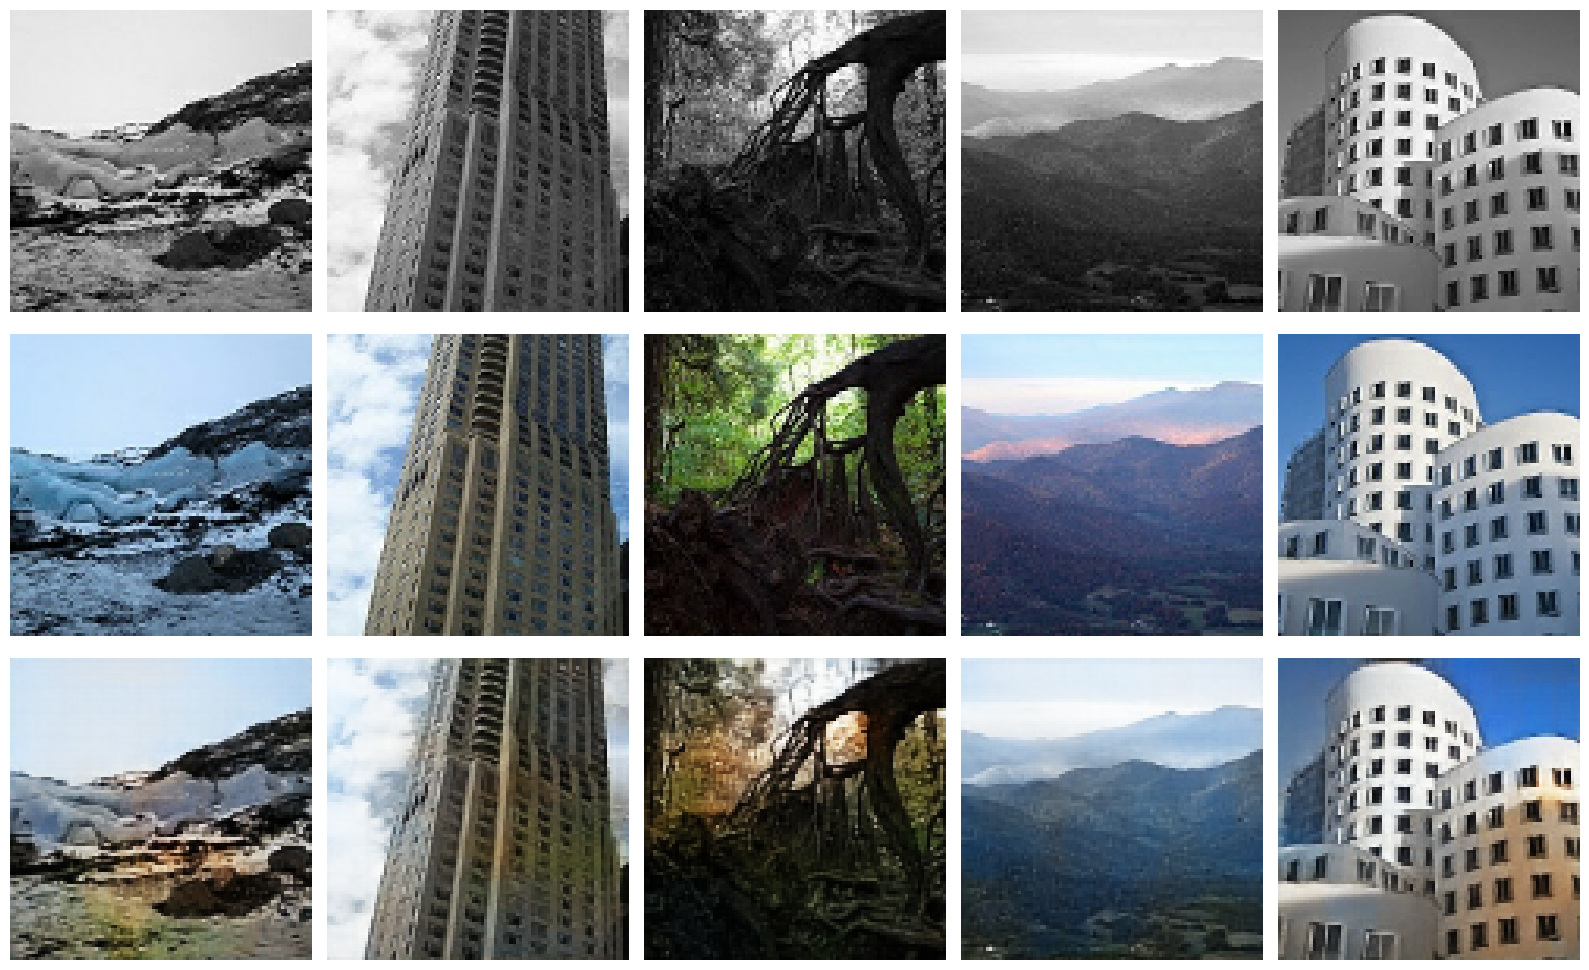

In [81]:
import matplotlib.pyplot as plt
import numpy as np

def plot_comparasion(dataset_batch, predictions, num_images=5, start_index=0):
    """
    Muestra comparativas entre imágenes originales, escala de grises y predicciones del modelo

    Args:
        dataset_batch: Batch de datos (tupla de tensores (gray_images, color_images))
        predictions: Array de predicciones del modelo (num_images, H, W, 3)
        num_images: Número de imágenes a mostrar
        start_index: Índice inicial dentro del batch
    """
    gray_images = dataset_batch[0][start_index:start_index+num_images].numpy()
    color_images = dataset_batch[1][start_index:start_index+num_images].numpy()

    # Asegurar que las predicciones tienen el mismo número de imágenes
    predictions = predictions[start_index:start_index+num_images]

    fig, axes = plt.subplots(3, num_images, figsize=(16, 10))
    if num_images == 1:
        axes = axes.reshape(3, 1)  # Para manejar correctamente el caso de 1 imagen

    # Mostrar imágenes
    for i in range(num_images):
        # Escala de grises (eliminar dimensión del canal si es necesario)
        axes[0, i].imshow(gray_images[i].squeeze(), cmap='gray')
        axes[0, i].axis('off')

        # Original a color
        axes[1, i].imshow(color_images[i])
        axes[1, i].axis('off')

        # Predicción
        axes[2, i].imshow(predictions[i])
        axes[2, i].axis('off')

    # Etiquetas
    axes[0, 0].set_ylabel('Escala de Grises', fontsize=12)
    axes[1, 0].set_ylabel('Original Color', fontsize=12)
    axes[2, 0].set_ylabel('Predicción Modelo', fontsize=12)

    plt.tight_layout()
    plt.show()


ini_imgs = 20
num_imgs = 5

# Obtener un batch del dataset de validación
test_batch = next(iter(dataset_valida.take(1)))
test_gray, test_color = test_batch

# Generar predicciones
predictions = model.predict(test_gray)


plot_comparasion(test_batch, predictions, num_images=num_imgs, start_index=ini_imgs)


In [78]:
model.save(MODELOS_DIR + 'colorear_rgb_model_c.keras')

In [79]:
color_auto_encoder = tf.keras.models.load_model(MODELOS_DIR + 'colorear_rgb_model_c.keras')
model.evaluate(dataset_valida)

27/27 ━━━━━━━━━━━━━━━━━━━━ 3s 90ms/step - loss: 0.0557


0.05456310883164406